# Identifier drift case studies (audit + explainability)

This notebook generates *manuscript-ready* qualitative evidence for IDTrack's core framing: identifier mapping is a reproducibility contract across **namespace × release × assembly**.

It automatically mines **case studies** from the IDTrack graph (using `explain=True`) and exports:

- Figure: `_outputs/_publication/figures/fig_drift_case_studies.pdf`
- Table (optional): `_outputs/_publication/tables/drift_case_studies.tex`
- Figure (taxonomy): `_outputs/_publication/figures/fig_drift_case_studies_taxonomy.pdf`
- Table (taxonomy): `_outputs/_publication/tables/drift_case_studies_taxonomy.csv`
- Table (taxonomy): `_outputs/_publication/tables/drift_case_studies_taxonomy.tex`

Caching:
- Case-study payloads (including explainability paths) are cached under `idtrack/docs/_notebooks/idtrack_cache/experiments/case_studies/`.
- If the cache is missing, the notebook computes it (graph loading can be memory-intensive).

## Interpretation guide (how to use these in the Results text)

- Each panel shows a single query identifier time-travelled into a target release and projected into a target namespace.
- Drift is not treated as "noise": a merge/split/retirement is a *historical curation event* that legitimately changes identity.
- The audit path is the marketing artifact: it turns a mapping into a rerunnable, inspectable claim rather than a black-box lookup.


In [1]:
from __future__ import annotations

import time
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt

try:
    import networkx as nx
except Exception as e:  # noqa: S110
    nx = None
    print('Warning: networkx not available:', e)

import os
import sys

# Add experiments/src to sys.path (layout-aware; works on Slurm and locally)
REPO_ROOT = Path(os.environ.get('REPO_ROOT', Path.cwd())).expanduser().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (
    (REPO_ROOT / 'idtrack').is_dir()
    and ((REPO_ROOT / 'reproducibility').is_dir() or (REPO_ROOT / 'idtrack' / 'reproducibility').is_dir())
):
    REPO_ROOT = REPO_ROOT.parent

REPRO_ROOT = REPO_ROOT / 'reproducibility' if (REPO_ROOT / 'reproducibility').is_dir() else REPO_ROOT / 'idtrack' / 'reproducibility'
EXPERIMENTS_SRC = REPRO_ROOT / 'experiments' / 'src'
if str(EXPERIMENTS_SRC) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_SRC))

from experiments_utils import (  # noqa: E402
    MANUSCRIPT_COLORS,
    atomic_write_text,
    notebook_context,
    read_pickle,
    save_figure,
    write_pickle,
)

ctx = notebook_context('case_studies', start=REPO_ROOT)
plt.rcParams.update({'savefig.dpi': 300})

IDTRACK_LOCAL_REPO = ctx.idtrack_local_repo
CACHE_DIR = ctx.experiment_cache
MANUSCRIPT_FIGURES = ctx.manuscript_figures
MANUSCRIPT_TABLES = ctx.manuscript_tables

print('Repo root:', REPO_ROOT)
print('IDTRACK_LOCAL_REPO:', IDTRACK_LOCAL_REPO)
print('CACHE_DIR:', CACHE_DIR)


Repo root: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack
IDTRACK_LOCAL_REPO: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache
CACHE_DIR: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/experiments/case_studies


In [2]:
# -------------------- Configuration --------------------

ORGANISM_ALIAS = 'human'
GRAPH_SNAPSHOT_RELEASE = 115
TO_RELEASE = 107
FINAL_DATABASE = 'HGNC Symbol'
STRATEGY = 'best'

# Mining settings
N_CANDIDATES_TO_SCAN = 3000
N_CASES = 6
RANDOM_SEED = 0

CASES_PKL = CACHE_DIR / (
    f"cases_{ORGANISM_ALIAS}_snapshot{GRAPH_SNAPSHOT_RELEASE}_to{TO_RELEASE}_final{FINAL_DATABASE}_"
    f"strategy{STRATEGY}_n{N_CASES}_seed{RANDOM_SEED}.pickle"
)

print('CASES_PKL:', CASES_PKL)


CASES_PKL: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/experiments/case_studies/cases_human_snapshot115_to107_finalHGNC Symbol_strategybest_n6_seed0.pickle


In [3]:
# -------------------- Mine case studies (cache-first) --------------------

import numpy as np

if CASES_PKL.exists():
    cases = read_pickle(CASES_PKL)
    print('Loaded:', CASES_PKL)
else:
    import idtrack

    rng = np.random.default_rng(RANDOM_SEED)

    api = idtrack.API(local_repository=str(IDTRACK_LOCAL_REPO))
    api.configure_logger()

    organism, latest = api.resolve_organism(ORGANISM_ALIAS)
    snapshot = max(int(GRAPH_SNAPSHOT_RELEASE), int(TO_RELEASE))
    if snapshot > int(latest):
        raise ValueError(f'snapshot_release={snapshot} exceeds latest={latest} for {ORGANISM_ALIAS}')

    print(f'Building/loading graph: {organism} snapshot_release={snapshot}')
    api.build_graph(organism_name=organism, snapshot_release=snapshot, calculate_caches=True)

    g = api.track.graph

    # Reservoir-sample ENSG identifiers without materializing the full list
    def reservoir_sample(prefix: str, k: int) -> list[str]:
        sample: list[str] = []
        n_seen = 0
        for node in g.nodes:
            if not isinstance(node, str) or not node.startswith(prefix):
                continue
            n_seen += 1
            if len(sample) < k:
                sample.append(node)
                continue
            j = int(rng.integers(0, n_seen))
            if j < k:
                sample[j] = node
        return sample

    candidates = reservoir_sample('ENSG', N_CANDIDATES_TO_SCAN)
    print('Sampled candidates:', len(candidates))

    def pick_release_for_ensembl(node: str) -> int | None:
        try:
            ranges = g.get_active_ranges_of_id[node]
        except Exception:
            return None
        if not ranges:
            return None
        lo, hi = ranges[int(rng.integers(0, len(ranges)))]
        hi_int = int(max(g.graph.get('confident_for_release', [snapshot]))) if hi == float('inf') else int(hi)
        if lo > hi_int:
            return None
        return int(rng.integers(int(lo), hi_int + 1))

    cases = []
    t0 = time.perf_counter()
    for q in candidates:
        if len(cases) >= N_CASES:
            break
        fr = pick_release_for_ensembl(q)
        if fr is None:
            continue

        res = api.convert_identifier(
            q,
            from_release=fr,
            to_release=int(TO_RELEASE),
            final_database=FINAL_DATABASE,
            strategy=STRATEGY,
            explain=True,
        )

        if res.get('no_corresponding') or res.get('no_conversion'):
            continue

        n_targets = len(res.get('target_id', []) or [])
        changed = (n_targets == 1 and res['target_id'][0] != res.get('query_id'))

        if n_targets > 1 or changed:
            cases.append({'from_release': fr, 'result': res})

    dt = time.perf_counter() - t0
    print(f'Collected {len(cases)} cases in {dt:.1f}s')

    write_pickle(cases, CASES_PKL)
    print('Saved:', CASES_PKL)

cases


2026-01-18 14:29:22 INFO:verify_organism: Ensembl Rest API query to get the organism names and associated releases.


Building/loading graph: homo_sapiens snapshot_release=115


2026-01-18 14:29:47 INFO:database_manager: Using assembly-specific release range for homo_sapiens assembly 38: releases 76-115 (from config [76, None])
2026-01-18 14:30:40 INFO:graph_maker: The graph is being read: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/graph_homo_sapiens_min48_max115_narrow.pickle
2026-01-18 14:32:32 INFO:the_graph: Cached properties being calculated: available_genome_assemblies
2026-01-18 14:32:32 INFO:the_graph: Cached properties being calculated: combined_edges
2026-01-18 14:33:44 INFO:the_graph: Cached properties being calculated: combined_edges_genes
2026-01-18 14:34:16 INFO:the_graph: Cached properties being calculated: combined_edges_assembly_specific_genes
2026-01-18 14:34:19 INFO:the_graph: Cached properties being calculated: lower_chars_graph
2026-01-18 14:34:21 INFO:the_graph: Cached properties being calculated: get_active_ranges_of_id
2026-01-18 14:34:57 INFO:the_graph: Cached properties being calculated: available

Sampled candidates: 3000
Collected 6 cases in 0.0s
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/experiments/case_studies/cases_human_snapshot115_to107_finalHGNC Symbol_strategybest_n6_seed0.pickle


[{'from_release': 48,
  'result': {'target_id': ['TPRX2'],
   'last_node': [('ENSG00000259009.5', 'TPRX2')],
   'final_database': 'HGNC Symbol',
   'graph_id': 'ENSG00000259009.Void',
   'query_id': 'ENSG00000259009.Void',
   'no_corresponding': False,
   'no_conversion': False,
   'no_target': False,
   'the_path': {('TPRX2',
     'ENSG00000259009.5'): (('ENSG00000259009.Void',
      'ENSG00000259009.1',
      0), ('ENSG00000259009.1', 'ENSG00000259009.2', 0), ('ENSG00000259009.2',
      'ENSG00000259009.3',
      0), ('ENSG00000259009.3', 'ENSG00000259009.4', 0), ('ENSG00000259009.4',
      'ENSG00000259009.5',
      0), ('ENSG00000259009.5', 'TPRX2', 0, 107))}}},
 {'from_release': 95,
  'result': {'target_id': ['ENSG00000266371.1'],
   'last_node': [('ENSG00000266371.1', 'ENSG00000266371.1')],
   'final_database': 'ensembl_gene',
   'graph_id': 'ENSG00000266371',
   'query_id': 'ENSG00000266371',
   'no_corresponding': False,
   'no_conversion': False,
   'no_target': True,
   'the_

Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/drift_case_studies.tex
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/case_studies/tables/drift_case_studies.tex
Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/docs/_notebooks/idtrack_cache/experiments/case_studies/drift_case_studies_metrics.csv
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_drift_case_studies_metrics.pdf


,case,query_id,from_release,to_release,final_database,n_targets,path_edges,path_nodes,path_nodes_ensembl,path_nodes_external,path_nodes_bridge
0,1,ENSG00000259009.Void,48,107,HGNC Symbol,1,6,7,6,1,0
1,2,ENSG00000266371,95,107,ensembl_gene,1,4,2,2,0,0
2,3,ENSG00000112200.9,55,107,HGNC Symbol,1,11,10,9,1,0
3,4,ENSG00000207298.Void,48,107,HGNC Symbol,1,2,3,2,1,0
4,5,ENSG00000148841.15,90,107,HGNC Symbol,1,3,4,3,1,0
5,6,ENSG00000246536,57,107,ensembl_gene,1,3,4,3,1,0


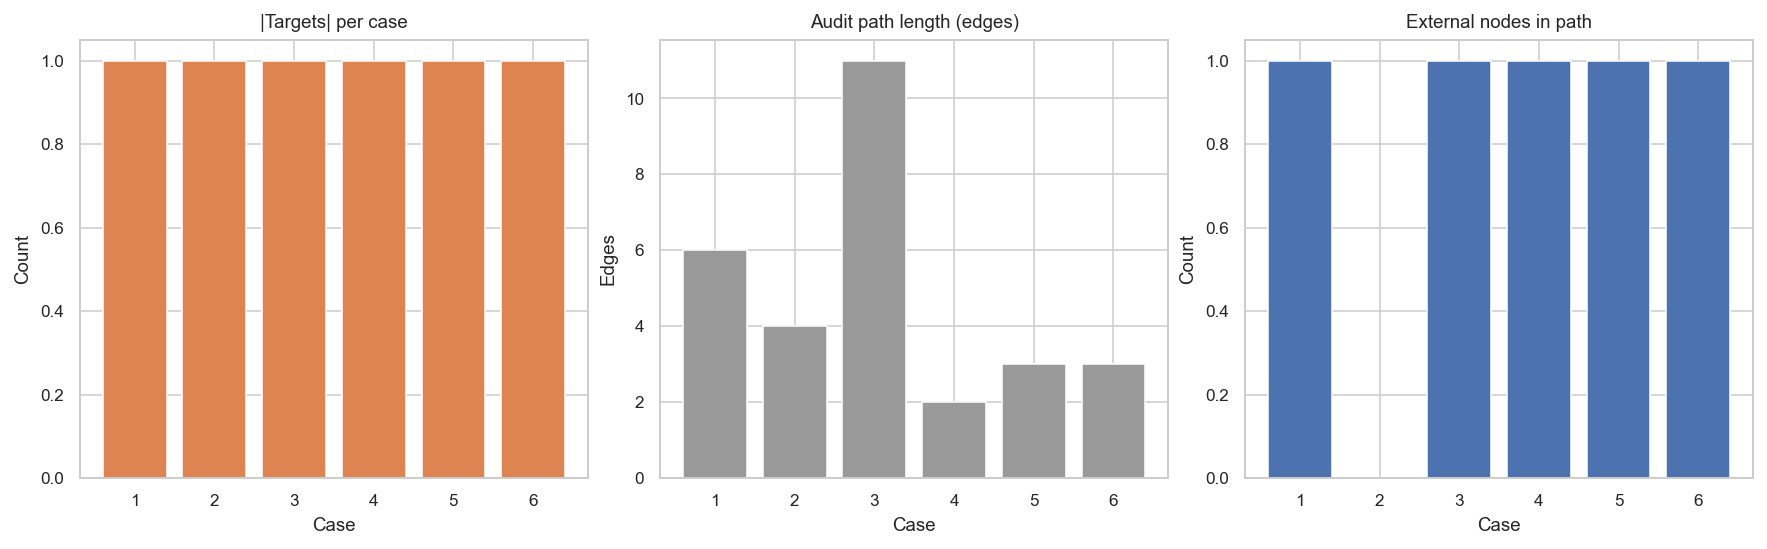

In [4]:
# -------------------- Summarize + export table --------------------

rows = []
for i, case in enumerate(cases, start=1):
    res = case['result']
    rows.append(
        {
            'case': i,
            'query_id': res.get('query_id'),
            'from_release': int(case.get('from_release')),
            'to_release': int(TO_RELEASE),
            'final_database': res.get('final_database'),
            'n_targets': len(res.get('target_id', []) or []),
            'targets': ', '.join(map(str, (res.get('target_id') or [])[:6])),
        }
    )

summary = pd.DataFrame(rows)
summary

# Optional LaTeX export (compact)
out_tex = MANUSCRIPT_TABLES / 'drift_case_studies.tex'

if summary.empty:
    print('No cases available; skipping LaTeX export.')
else:
    lines = []
    lines.append(r'\begin{table}[t]')
    lines.append(r'\caption{Identifier drift case studies mined from the IDTrack graph (audit-friendly, explainable conversions).}')
    lines.append(r'\label{tab:drift_cases}')
    lines.append(r'\centering')
    lines.append(r'\footnotesize')
    lines.append(r'\begin{tabular}{@{}r l r r r@{}}')
    lines.append(r'\toprule')
    lines.append(r'Case & Query & From & To & |Targets| \\')
    lines.append(r'\midrule')

    for r in summary.itertuples(index=False):
        lines.append(
            f"{r.case} & \\texttt{{{r.query_id}}} & {r.from_release} & {r.to_release} & {r.n_targets} " + r"\\"
        )

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(r'\end{table}')

    tex = '\n'.join(lines) + '\n'
    atomic_write_text(out_tex, tex)
    atomic_write_text((ctx.experiment_outputs / 'tables' / out_tex.name), tex)
    print('Wrote:', out_tex)
    print('Wrote:', (ctx.experiment_outputs / 'tables' / out_tex.name))

# Additional diagnostic export (marketing): per-case path metrics
metrics_rows = []
for i, case in enumerate(cases, start=1):
    res = case['result']
    paths = res.get('the_path', {}) or {}

    n_edges = 0
    nodes_in_order = []
    if paths:
        key = next(iter(paths.keys()))
        for step in (paths.get(key) or []):
            if not isinstance(step, (list, tuple)) or len(step) < 2:
                continue
            u, v = step[0], step[1]
            if u is None or v is None:
                continue
            n_edges += 1
            nodes_in_order.extend([u, v])

    uniq = []
    seen = set()
    for n in nodes_in_order:
        if n in seen:
            continue
        seen.add(n)
        uniq.append(n)

    n_nodes = len(uniq)
    n_ensembl = sum(1 for n in uniq if isinstance(n, str) and str(n).startswith('ENS'))
    n_external = sum(1 for n in uniq if isinstance(n, str) and not str(n).startswith('ENS'))
    n_bridge = sum(1 for n in uniq if isinstance(n, int))

    metrics_rows.append(
        {
            'case': i,
            'query_id': res.get('query_id'),
            'from_release': int(case.get('from_release')),
            'to_release': int(TO_RELEASE),
            'final_database': res.get('final_database'),
            'n_targets': len(res.get('target_id', []) or []),
            'path_edges': int(n_edges),
            'path_nodes': int(n_nodes),
            'path_nodes_ensembl': int(n_ensembl),
            'path_nodes_external': int(n_external),
            'path_nodes_bridge': int(n_bridge),
        }
    )

metrics = pd.DataFrame(metrics_rows)
metrics_path = CACHE_DIR / 'drift_case_studies_metrics.csv'
metrics.to_csv(metrics_path, index=False)
print('Wrote:', metrics_path)

if not metrics.empty:
    figm, axesm = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
    axm0, axm1, axm2 = axesm

    axm0.bar(metrics['case'], metrics['n_targets'], color=MANUSCRIPT_COLORS['1→n'])
    axm0.set_title('|Targets| per case')
    axm0.set_xlabel('Case')
    axm0.set_ylabel('Count')

    axm1.bar(metrics['case'], metrics['path_edges'], color=MANUSCRIPT_COLORS['neutral'])
    axm1.set_title('Audit path length (edges)')
    axm1.set_xlabel('Case')
    axm1.set_ylabel('Edges')

    axm2.bar(metrics['case'], metrics['path_nodes_external'], color=MANUSCRIPT_COLORS['1→1'])
    axm2.set_title('External nodes in path')
    axm2.set_xlabel('Case')
    axm2.set_ylabel('Count')

    writtenm = save_figure(figm, 'fig_drift_case_studies_metrics.pdf', ctx, formats=('pdf',))
    print('Saved:', writtenm['pdf'])

metrics


Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_drift_case_studies.pdf


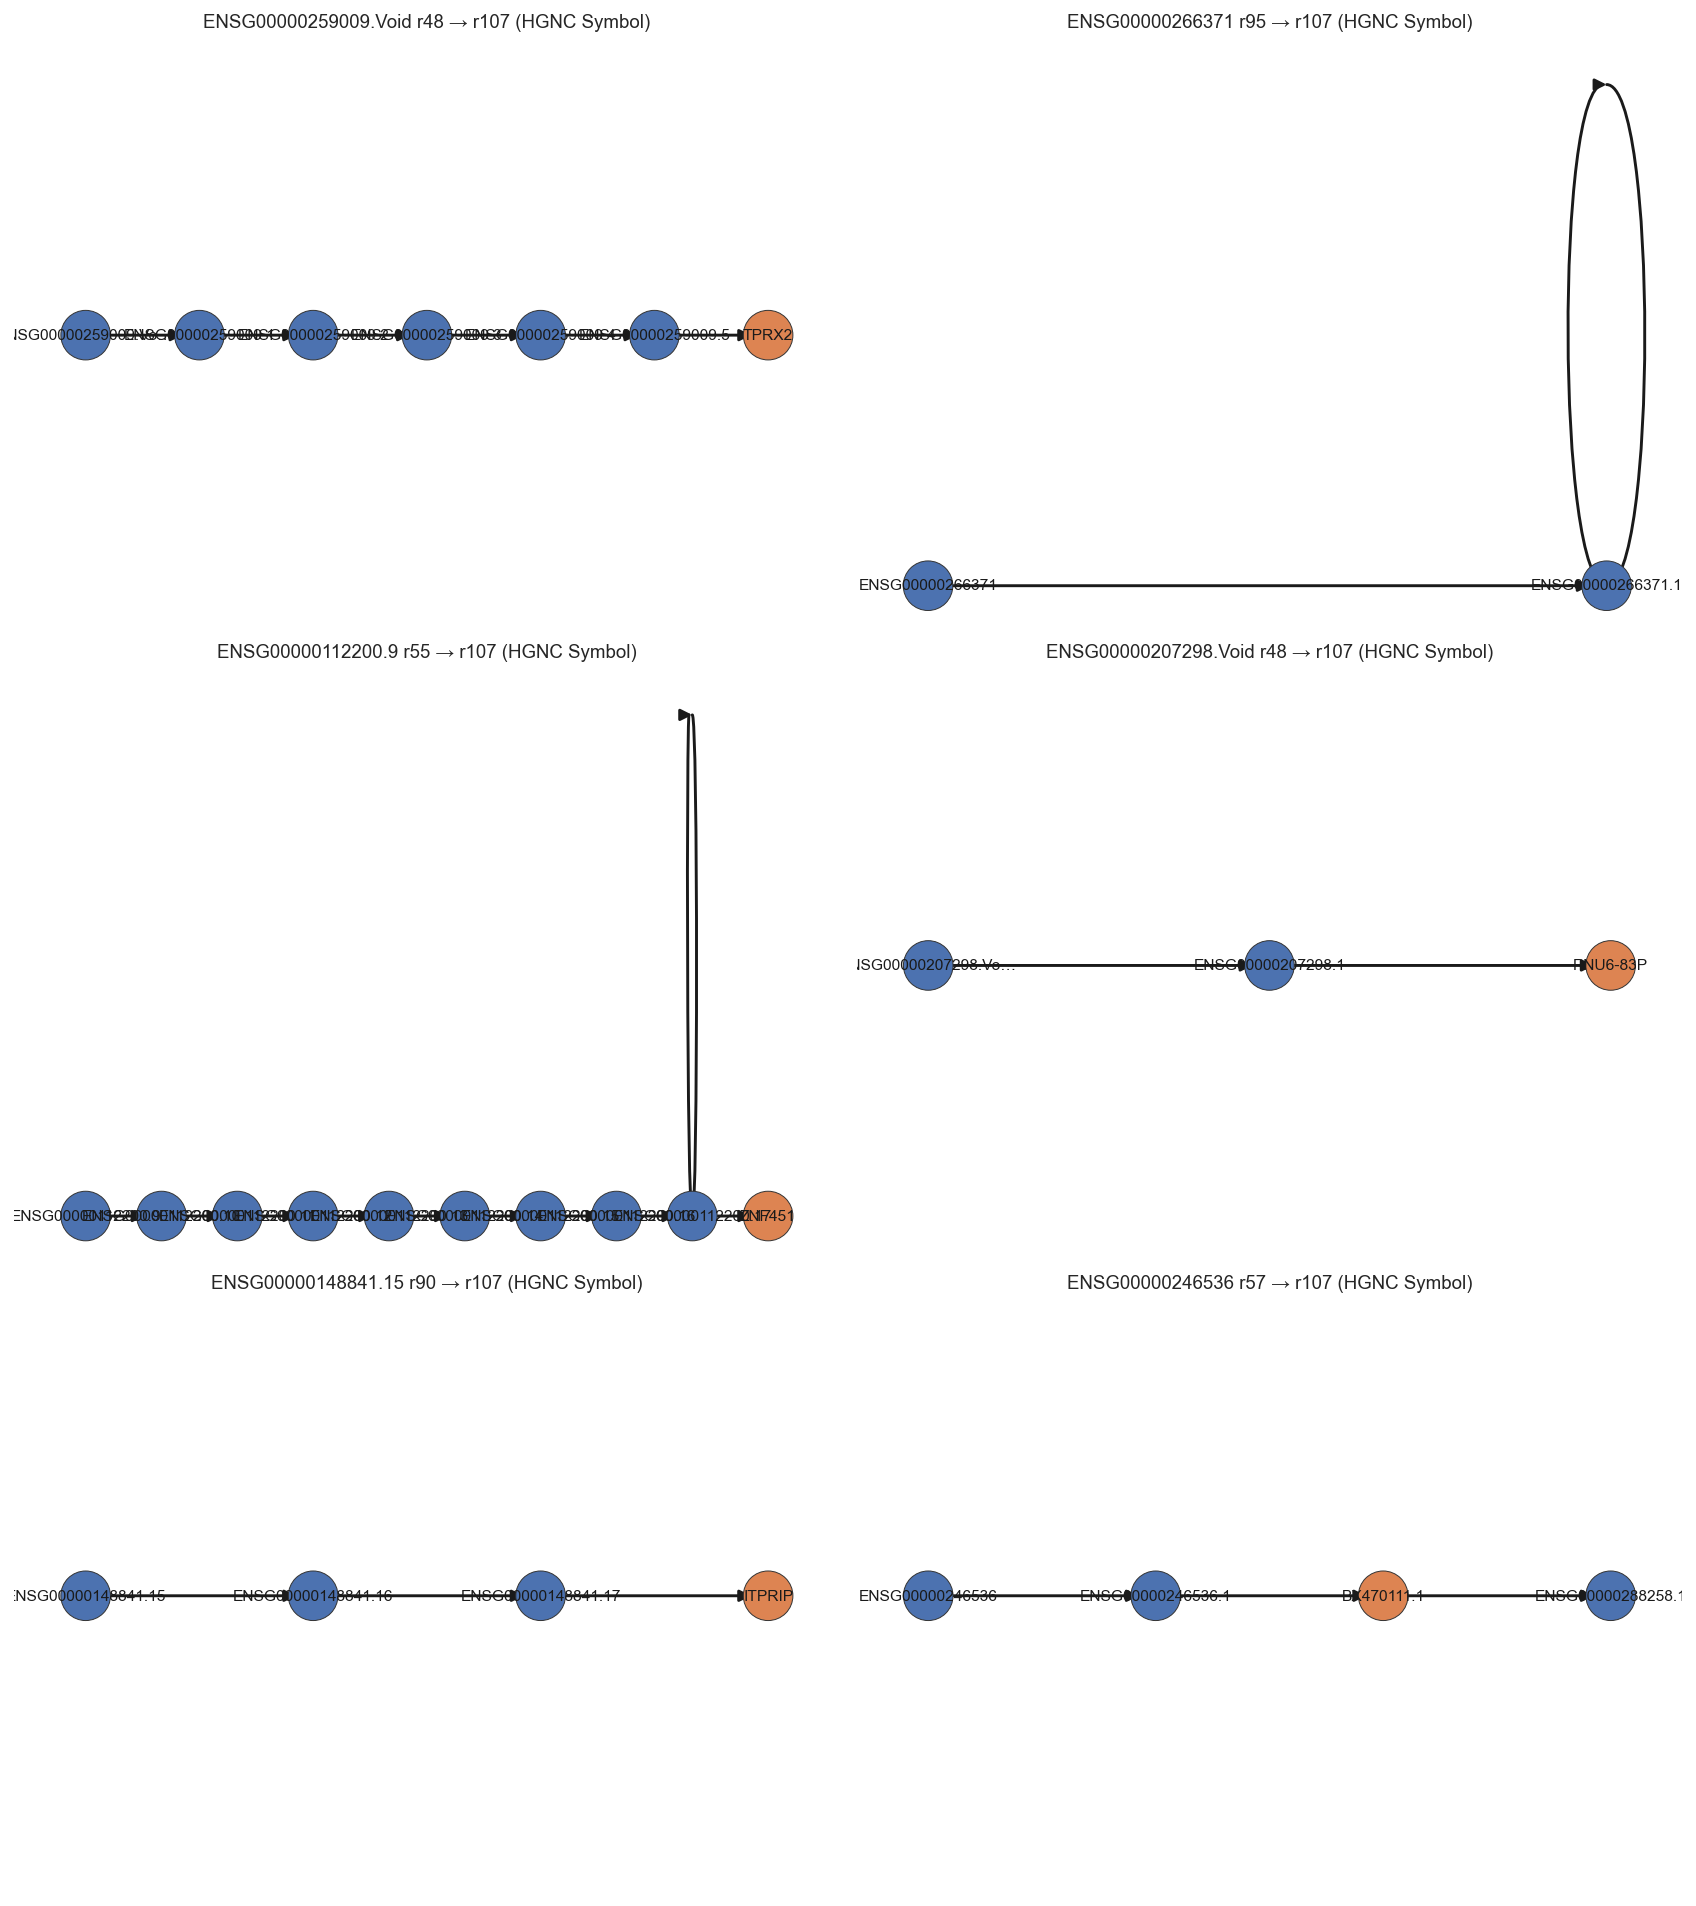

In [5]:
# -------------------- Plot case-study paths --------------------

import numpy as np

if not cases:
    print('No cases to plot.')
elif nx is None:
    print('networkx not available; skipping path plots.')
else:
    def node_kind(n) -> str:
        if n is None:
            return 'none'
        if isinstance(n, int):
            return 'bridge'
        s = str(n)
        if s.startswith('ENS'):
            return 'ensembl'
        return 'external'

    kind_color = {
        'ensembl': MANUSCRIPT_COLORS['1→1'],
        'external': MANUSCRIPT_COLORS['1→n'],
        'bridge': MANUSCRIPT_COLORS['neutral'],
        'none': '#FFFFFF',
    }

    n = min(len(cases), N_CASES)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.5 * nrows), constrained_layout=True)
    axes = list(np.ravel(axes))

    for ax, case in zip(axes, cases[:n]):
        res = case['result']
        paths = res.get('the_path', {})
        if not paths:
            ax.axis('off')
            ax.set_title(f"{res.get('query_id')} (no path)")
            continue

        # Plot the first available target path
        key = next(iter(paths.keys()))
        path_steps = paths[key]

        edges = []
        nodes_in_order = []
        for step in path_steps:
            if not isinstance(step, (list, tuple)) or len(step) < 2:
                continue
            u, v = step[0], step[1]
            if u is None or v is None:
                continue
            edges.append((u, v))
            nodes_in_order.extend([u, v])

        G = nx.DiGraph()
        G.add_edges_from(edges)

        # Simple left-to-right layout following the observed order
        uniq = []
        seen = set()
        for v in nodes_in_order:
            if v in seen:
                continue
            seen.add(v)
            uniq.append(v)

        pos = {v: (i, 0.0) for i, v in enumerate(uniq)}

        node_colors = [kind_color.get(node_kind(v), '#CCCCCC') for v in G.nodes]
        nx.draw_networkx_edges(G, pos=pos, ax=ax, arrows=True, arrowstyle='-|>', arrowsize=12, width=1.5)
        nx.draw_networkx_nodes(G, pos=pos, ax=ax, node_size=650, node_color=node_colors, linewidths=0.5, edgecolors='#333333')

        labels = {v: (str(v) if len(str(v)) <= 18 else str(v)[:18] + '…') for v in G.nodes}
        nx.draw_networkx_labels(G, pos=pos, ax=ax, labels=labels, font_size=8)

        ax.set_axis_off()
        ax.set_title(f"{res.get('query_id')} r{case.get('from_release')} → r{TO_RELEASE} ({FINAL_DATABASE})")

    for ax in axes[n:]:
        ax.axis('off')

    written = save_figure(fig, 'fig_drift_case_studies.pdf', ctx, formats=('pdf',))
    print('Saved:', written['pdf'])


# Marketing extension: case-study taxonomy (compact, reportable metrics)

A reader should understand *why* a case is interesting without reading the full path diagram.

This section extracts compact, reportable metrics per case:

- mapping outcome (1→0 / 1→1 / 1→n)
- number of targets (ambiguity)
- path length (audit complexity)
- presence of external nodes (external bridging involvement)


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/drift_case_studies_taxonomy.csv


,case,query_id,from_release,to_release,final_database,mapping,n_targets,path_len,n_external_nodes_in_path
0,1,ENSG00000259009.Void,48,107,HGNC Symbol,1:1,1,11,1
1,2,ENSG00000266371,95,107,ensembl_gene,1:1,1,7,0
2,3,ENSG00000112200.9,55,107,HGNC Symbol,1:1,1,21,1
3,4,ENSG00000207298.Void,48,107,HGNC Symbol,1:1,1,3,1
4,5,ENSG00000148841.15,90,107,HGNC Symbol,1:1,1,5,1
5,6,ENSG00000246536,57,107,ensembl_gene,1:1,1,5,2


Wrote: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/tables/drift_case_studies_taxonomy.tex
Saved: /ictstr01/home/icb/kemal.inecik/work/codes/idtrack/reproducibility/experiments/_outputs/_publication/figures/fig_drift_case_studies_taxonomy.pdf


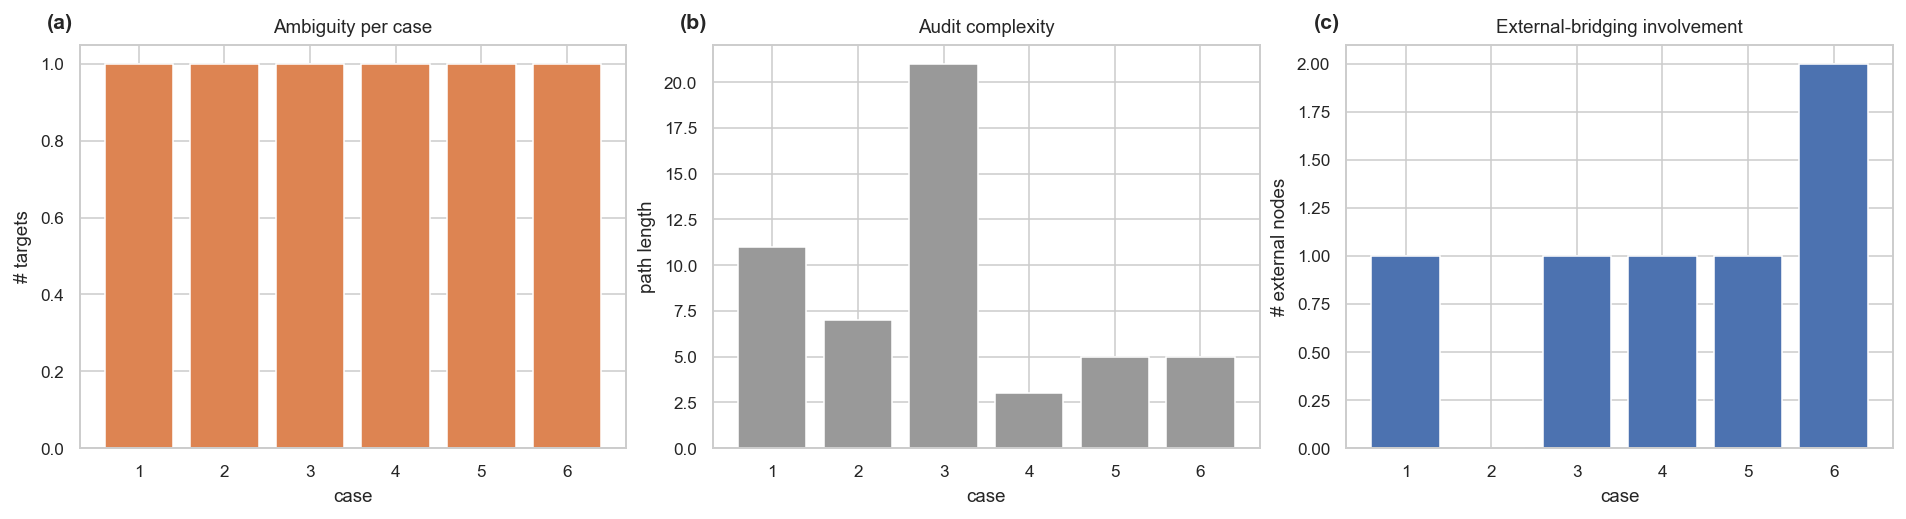

In [6]:
from experiments_utils import atomic_write_dataframe_csv, atomic_write_dataframe_latex, label_panels  # noqa: E402

def _flatten_paths(result: dict) -> list:
    paths = result.get('the_path') or {}
    if not isinstance(paths, dict) or not paths:
        return []
    first_key = next(iter(paths.keys()))
    steps = paths.get(first_key) or []
    nodes = []
    for step in steps:
        if not isinstance(step, (list, tuple)) or len(step) < 2:
            continue
        nodes.extend([step[0], step[1]])
    return [n for n in nodes if n is not None]

rows = []
for i, case in enumerate(cases or [], start=1):
    res = case.get('result') or {}
    q = res.get('query_id')
    targets = res.get('target_id') or []
    n_targets = len(targets)
    mapping = '1:0' if n_targets == 0 else ('1:1' if n_targets == 1 else '1:n')

    nodes = _flatten_paths(res)
    n_external = 0
    for n in nodes:
        if isinstance(n, str) and (not n.startswith('ENS')):
            n_external += 1
    rows.append(
        {
            'case': i,
            'query_id': str(q),
            'from_release': int(case.get('from_release')),
            'to_release': int(TO_RELEASE),
            'final_database': str(res.get('final_database')),
            'mapping': mapping,
            'n_targets': int(n_targets),
            'path_len': (len(nodes) - 1) if nodes else None,
            'n_external_nodes_in_path': int(n_external),
        }
    )

tax = pd.DataFrame(rows)
if tax.empty:
    print('No taxonomy rows; are cases available?')
else:
    out_csv = MANUSCRIPT_TABLES / 'drift_case_studies_taxonomy.csv'
    atomic_write_dataframe_csv(tax, out_csv, index=False)
    atomic_write_dataframe_csv(tax, ctx.experiment_outputs / 'tables' / out_csv.name, index=False)
    print('Wrote:', out_csv)
    display(tax)

    out_tex = MANUSCRIPT_TABLES / 'drift_case_studies_taxonomy.tex'
    atomic_write_dataframe_latex(tax.fillna(''), out_tex, index=False, escape=True)
    atomic_write_dataframe_latex(tax.fillna(''), ctx.experiment_outputs / 'tables' / out_tex.name, index=False)
    print('Wrote:', out_tex)

    figT, axesT = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)
    ax0, ax1, ax2 = axesT
    ax0.bar(tax['case'], tax['n_targets'], color=MANUSCRIPT_COLORS['1→n'])
    ax0.set_xlabel('case')
    ax0.set_ylabel('# targets')
    ax0.set_title('Ambiguity per case')

    ax1.bar(tax['case'], tax['path_len'].fillna(0), color=MANUSCRIPT_COLORS['neutral'])
    ax1.set_xlabel('case')
    ax1.set_ylabel('path length')
    ax1.set_title('Audit complexity')

    ax2.bar(tax['case'], tax['n_external_nodes_in_path'], color=MANUSCRIPT_COLORS['1→1'])
    ax2.set_xlabel('case')
    ax2.set_ylabel('# external nodes')
    ax2.set_title('External-bridging involvement')

    label_panels(axesT)
    writtenT = save_figure(figT, 'fig_drift_case_studies_taxonomy.pdf', ctx, formats=('pdf',))
    print('Saved:', writtenT['pdf'])
